In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

import numpy as np
import pandas as pd

from reparameterization import load_param

# Table 2.1: D-optimal

In [2]:
from optimal_designs import D_optimal

model_names = ['logistic', 'probit', 'skewed logit', 'complementary log-log', 'gumbel']
g_val = 0.5
m_val = 0.5  # Required for the skewed logit asymmetry

results = []

for model in model_names:
    # 1. Load the parameter dictionary and extract the probability function H
    params = load_param(model=model, g=g_val, m=m_val)
    H_func = params['H']
    
    # 2. Calculate the unrestricted D-optimal design
    # Returns a pd.Series where index = induced doses (z), values = weights (w)
    opt_design = D_optimal(model=model, g=g_val, m=m_val)
    
    # 3. Evaluate toxicities (probabilities of response) at the optimal doses
    opt_doses = opt_design.index.to_numpy()
    toxicities = np.round(H_func(opt_doses), 3)
    
    # 4. Extract and round the optimal weights
    weights = np.round(opt_design.to_numpy(), 3)
    
    # 5. Append the row data as a dictionary
    results.append({
        'Model': model.capitalize(),
        'Toxicity': (float(toxicities[0]), float(toxicities[1])),
        'Weights': (float(weights[0]), float(weights[1]))
    })

# Generate and display the final DataFrame (Table 2.1)
df_table_2_1 = pd.DataFrame(results).set_index('Model')
df_table_2_1

,Toxicity,Weights
Model,,
Logistic,"(0.176, 0.824)","(0.5, 0.5)"
Probit,"(0.128, 0.872)","(0.5, 0.5)"
Skewed logit,"(0.117, 0.697)","(0.5, 0.5)"
Complementary log-log,"(0.231, 0.93)","(0.5, 0.5)"
Gumbel,"(0.07, 0.769)","(0.5, 0.5)"


# Tables 2.2 and 2.3: standarized A-optimal designs

In [3]:
from optimal_designs import A_optimal

def generate_Aoptimal_table(model_name: str, gamma_values: np.ndarray, m_val: float = 0.5) -> pd.DataFrame:
    """
    Generates a summary table of A-optimal unrestricted designs for a given model.
    
    Args:
        model_name (str): The statistical model to evaluate (e.g., 'logistic', 'skewed logit').
        gamma_values (np.ndarray): An array of gamma values to iterate over.
        m_val (float): Skewness parameter, primarily used for asymmetric models. Default is 0.5.
        
    Returns:
        pd.DataFrame: A table containing toxicities and weights, indexed by gamma.
    """
    # Initialize an empty list to store the row records
    # This is more efficient than appending to a DataFrame inside a loop
    results = []
    
    for g_val in gamma_values:
        # Load the mathematical parameters and the probability function H for the current gamma
        params = load_param(model=model_name, g=g_val, m=m_val)
        H_func = params['H']
        
        # Compute the unrestricted A-optimal design
        opt_design = A_optimal(model=model_name, g=g_val, m=m_val)
        
        # Extract the optimal doses (z) and evaluate their respective toxicities
        opt_doses = opt_design.index.to_numpy()
        toxicities = np.round(H_func(opt_doses), 3)
        
        # Extract the optimal weights (w) allocated to each dose
        weights = np.round(opt_design.to_numpy(), 3)
        
        # Append the calculated metrics as a dictionary for this specific gamma iteration
        results.append({
            'Gamma (g)': g_val,
            'Toxicity': (float(toxicities[0]), float(toxicities[1])),
            'Weights': (float(weights[0]), float(weights[1]))
        })
        
    # Convert the list of dictionaries into a pandas DataFrame and set Gamma as the index for clean display
    return pd.DataFrame(results).set_index('Gamma (g)')

In [4]:
# Para los modelos simétricos, solo necesitamos gammas del 0.1 al 0.5
gamma_sym = np.arange(1, 6) / 10.0  

df_logistic = generate_Aoptimal_table('logistic', gamma_sym)

df_probit = generate_Aoptimal_table('probit', gamma_sym)

pd.concat([df_logistic, df_probit], axis = 1)

,Toxicity,Weights,Toxicity,Weights
Gamma (g),,,,
0.1,"(0.118, 0.882)","(0.682, 0.318)","(0.09, 0.91)","(0.688, 0.312)"
0.2,"(0.146, 0.854)","(0.677, 0.323)","(0.111, 0.889)","(0.666, 0.334)"
0.3,"(0.169, 0.831)","(0.635, 0.365)","(0.126, 0.874)","(0.62, 0.38)"
0.4,"(0.184, 0.816)","(0.573, 0.427)","(0.136, 0.864)","(0.563, 0.437)"
0.5,"(0.189, 0.811)","(0.5, 0.5)","(0.14, 0.86)","(0.5, 0.5)"


In [5]:
# Para los modelos asimétricos, exploramos gammas del 0.1 al 0.9
gamma_asym = np.arange(1, 10) / 10.0  

df_skewed = generate_Aoptimal_table('skewed logit', gamma_asym, m_val=0.5)

df_cloglog = generate_Aoptimal_table('complementary log-log', gamma_asym)

df_gumbel = generate_Aoptimal_table('gumbel', gamma_asym)

pd.concat([df_skewed, df_cloglog, df_gumbel], axis = 1)



,Toxicity,Weights,Toxicity,Weights,Toxicity,Weights
Gamma (g),,,,,,
0.1,"(0.084, 0.756)","(0.75, 0.25)","(0.144, 0.963)","(0.751, 0.249)","(0.059, 0.796)","(0.619, 0.381)"
0.2,"(0.109, 0.711)","(0.7, 0.3)","(0.17, 0.954)","(0.754, 0.246)","(0.072, 0.765)","(0.561, 0.439)"
0.3,"(0.124, 0.686)","(0.618, 0.382)","(0.197, 0.944)","(0.733, 0.267)","(0.078, 0.751)","(0.489, 0.511)"
0.4,"(0.127, 0.68)","(0.529, 0.471)","(0.221, 0.935)","(0.696, 0.304)","(0.078, 0.751)","(0.418, 0.582)"
0.5,"(0.121, 0.69)","(0.451, 0.549)","(0.239, 0.927)","(0.645, 0.355)","(0.073, 0.761)","(0.355, 0.645)"
0.6,"(0.109, 0.711)","(0.397, 0.603)","(0.249, 0.922)","(0.582, 0.418)","(0.065, 0.779)","(0.304, 0.696)"
0.7,"(0.095, 0.736)","(0.371, 0.629)","(0.249, 0.922)","(0.511, 0.489)","(0.056, 0.803)","(0.267, 0.733)"
0.8,"(0.081, 0.762)","(0.38, 0.62)","(0.235, 0.928)","(0.439, 0.561)","(0.046, 0.83)","(0.246, 0.754)"
0.9,"(0.071, 0.784)","(0.421, 0.579)","(0.204, 0.941)","(0.381, 0.619)","(0.037, 0.856)","(0.249, 0.751)"


# Tables 2.4 and 2.5, E-optimal design

In [6]:
from optimal_designs import E_optimal

def generate_Eoptimal_table(model_name: str, gamma_values: np.ndarray, m_val: float = 0.5) -> pd.DataFrame:
    """
    Generates a summary table of A-optimal unrestricted designs for a given model.
    
    Args:
        model_name (str): The statistical model to evaluate (e.g., 'logistic', 'skewed logit').
        gamma_values (np.ndarray): An array of gamma values to iterate over.
        m_val (float): Skewness parameter, primarily used for asymmetric models. Default is 0.5.
        
    Returns:
        pd.DataFrame: A table containing toxicities and weights, indexed by gamma.
    """
    # Initialize an empty list to store the row records
    # This is more efficient than appending to a DataFrame inside a loop
    results = []
    
    for g_val in gamma_values:
        # Load the mathematical parameters and the probability function H for the current gamma
        params = load_param(model=model_name, g=g_val, m=m_val)
        H_func = params['H']
        
        # Compute the unrestricted A-optimal design
        opt_design = E_optimal(model=model_name, g=g_val, m=m_val)
        
        # Extract the optimal doses (z) and evaluate their respective toxicities
        opt_doses = opt_design.index.to_numpy()
        toxicities = np.round(H_func(opt_doses), 3)
        
        # Extract the optimal weights (w) allocated to each dose
        weights = np.round(opt_design.to_numpy(), 3)
        
        # Append the calculated metrics as a dictionary for this specific gamma iteration
        results.append({
            'Gamma (g)': g_val,
            'Toxicity': (float(toxicities[0]), float(toxicities[1])),
            'Weights': (float(weights[0]), float(weights[1]))
        })
        
    # Convert the list of dictionaries into a pandas DataFrame and set Gamma as the index for clean display
    return pd.DataFrame(results).set_index('Gamma (g)')

In [7]:
# Para los modelos simétricos, solo necesitamos gammas del 0.1 al 0.5
gamma_sym = np.arange(1, 6) / 10.0  

df_logistic = generate_Eoptimal_table('logistic', gamma_sym)

df_probit = generate_Eoptimal_table('probit', gamma_sym)

pd.concat([df_logistic, df_probit], axis = 1)

,Toxicity,Weights,Toxicity,Weights
Gamma (g),,,,
0.1,"(0.042, 0.958)","(0.853, 0.147)","(0.032, 0.968)","(0.846, 0.154)"
0.2,"(0.103, 0.897)","(0.821, 0.179)","(0.081, 0.919)","(0.801, 0.199)"
0.3,"(0.158, 0.842)","(0.753, 0.247)","(0.124, 0.876)","(0.727, 0.273)"
0.4,"(0.196, 0.804)","(0.644, 0.356)","(0.154, 0.846)","(0.624, 0.376)"
0.5,"(0.21, 0.79)","(0.5, 0.5)","(0.164, 0.836)","(0.5, 0.5)"


In [8]:
# Para los modelos asimétricos, exploramos gammas del 0.1 al 0.9
gamma_asym = np.arange(1, 10) / 10.0  

df_skewed = generate_Eoptimal_table('skewed logit', gamma_asym, m_val=0.5)

df_cloglog = generate_Eoptimal_table('complementary log-log', gamma_asym)

df_gumbel = generate_Eoptimal_table('gumbel', gamma_asym)

pd.concat([df_skewed, df_cloglog, df_gumbel], axis = 1)



,Toxicity,Weights,Toxicity,Weights,Toxicity,Weights
Gamma (g),,,,,,
0.1,"(0.056, 0.816)","(0.875, 0.125)","(0.118, 0.971)","(0.806, 0.194)","(0.039, 0.851)","(0.729, 0.271)"
0.2,"(0.098, 0.731)","(0.845, 0.155)","(0.118, 0.971)","(0.873, 0.127)","(0.075, 0.756)","(0.621, 0.379)"
0.3,"(0.135, 0.667)","(0.724, 0.276)","(0.146, 0.963)","(0.887, 0.113)","(0.093, 0.716)","(0.479, 0.521)"
0.4,"(0.144, 0.651)","(0.557, 0.443)","(0.204, 0.941)","(0.84, 0.16)","(0.093, 0.717)","(0.34, 0.66)"
0.5,"(0.128, 0.678)","(0.403, 0.597)","(0.253, 0.921)","(0.767, 0.233)","(0.079, 0.747)","(0.233, 0.767)"
0.6,"(0.097, 0.733)","(0.301, 0.699)","(0.283, 0.907)","(0.66, 0.34)","(0.059, 0.796)","(0.16, 0.84)"
0.7,"(0.061, 0.804)","(0.244, 0.756)","(0.284, 0.907)","(0.521, 0.479)","(0.037, 0.854)","(0.113, 0.887)"
0.8,"(0.056, 0.816)","(0.299, 0.701)","(0.244, 0.925)","(0.379, 0.621)","(0.029, 0.882)","(0.127, 0.873)"
0.9,"(0.056, 0.816)","(0.389, 0.611)","(0.149, 0.961)","(0.271, 0.729)","(0.029, 0.882)","(0.194, 0.806)"


# Efficiencies

In [9]:
import numpy as np
import pandas as pd

from optimal_designs import D_optimal, A_optimal,E_optimal

from reparameterization import load_param, eff_eta, eff_mu


model_name = 'logistic'
g_classical = 0.5

# Generate gamma values: [0.10, 0.15, ..., 0.90]
gamma_values = np.arange(2, 19) / 20.0  

# =============================================================================
# 1. CALCULATE CLASSICAL DESIGNS (Assuming Gamma = 0.5)
# =============================================================================
params_classical = load_param(g=g_classical, model=model_name)
H_classical = params_classical['H']

dis_A_classical = A_optimal(g=g_classical, model=model_name)
dis_E_classical = E_optimal(g=g_classical, model=model_name)

# Translate optimal doses to invariant probabilities
prob_A_classical = H_classical(dis_A_classical.index.to_numpy())
prob_E_classical = H_classical(dis_E_classical.index.to_numpy())

# =============================================================================
# 2. EVALUATE EFFICIENCIES ACROSS GAMMA RANGE
# =============================================================================
results = []

for g_val in gamma_values:
    params_curr = load_param(g=g_val, model=model_name)
    H_inv_curr = params_curr['H_inv']
    
    # Define all designs to evaluate in a single dictionary
    designs_to_evaluate = {
        'D': D_optimal(g=g_val, model=model_name),
        
        'A_Classical': pd.Series(dis_A_classical.values, index=H_inv_curr(prob_A_classical)),
        'A_Curr': A_optimal(g=g_val, model=model_name),
        
        'E_Classical': pd.Series(dis_E_classical.values, index=H_inv_curr(prob_E_classical)),
        'E_Curr': E_optimal(g=g_val, model=model_name)
    }
    
    # Initialize the row data with the current gamma
    row_data = {'Gamma': g_val}
    
    # Loop through the dictionary to calculate efficiencies dynamically
    for design_name, design_series in designs_to_evaluate.items():
        row_data[f'{design_name}_Eff_mu'] = eff_mu(design_series, g=g_val, model=model_name)
        row_data[f'{design_name}_Eff_eta'] = eff_eta(design_series, g=g_val, model=model_name)
        
    results.append(row_data)

# Convert to DataFrame for easy visualization or plotting
df_efficiencies = pd.DataFrame(results).set_index('Gamma')
df_efficiencies

,D_Eff_mu,D_Eff_eta,A_Classical_Eff_mu,A_Classical_Eff_eta,A_Curr_Eff_mu,A_Curr_Eff_eta,E_Classical_Eff_mu,E_Classical_Eff_eta,E_Curr_Eff_mu,E_Curr_Eff_eta
Gamma,,,,,,,,,,
0.10,0.532485,0.786662,0.519924,0.740346,0.717513,0.831835,0.491673,0.663384,0.451754,0.451754
0.15,0.502695,0.786662,0.497126,0.740346,0.665855,0.797106,0.479528,0.663384,0.531236,0.531236
0.20,0.501760,0.786662,0.502648,0.740346,0.642222,0.775578,0.495038,0.663384,0.579282,0.579282
0.25,0.513450,0.786662,0.521048,0.740346,0.629568,0.761752,0.524320,0.663384,0.610792,0.610792
0.30,0.530758,0.786661,0.545346,0.740346,0.622180,0.752696,0.560649,0.663384,0.632220,0.632220
0.35,0.549230,0.786661,0.570664,0.740346,0.617695,0.746775,0.598460,0.663384,0.646800,0.646800
0.40,0.565358,0.786662,0.592720,0.740346,0.615004,0.743054,0.631896,0.663384,0.656284,0.656284
0.45,0.576321,0.786661,0.607762,0.740346,0.613560,0.741002,0.655070,0.663384,0.661647,0.661647
0.50,0.580203,0.786660,0.613105,0.740346,0.613105,0.740346,0.663384,0.663384,0.663384,0.663384


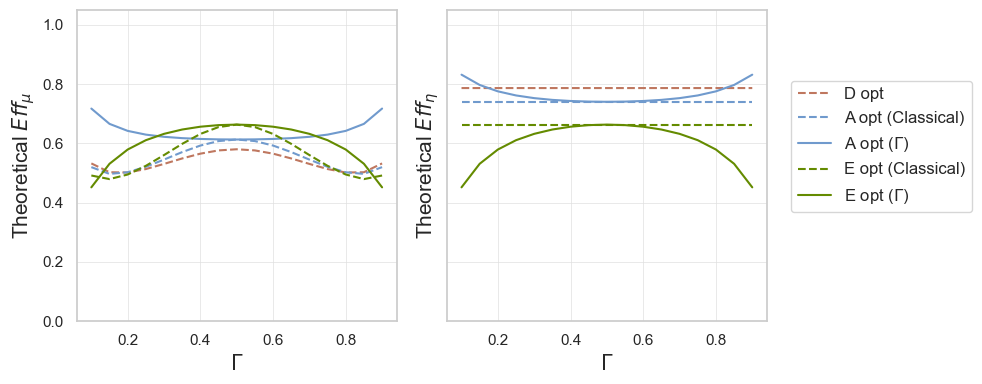

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de estilo global
sns.set_theme(
    style="whitegrid", 
    rc={
        "axes.grid": True,
        "grid.color": "#e0e0e0", 
        "grid.linewidth": 0.5,
        "axes.facecolor": "white" 
    }
)

# Diccionario de colores del proyecto
COLORS = {
    'r': '#bf775f', 'r2': '#d5572c', 'o': "#e38800", 'y': '#e6d26b',
    'g': "#648B00", 'c': '#98cacd', 'b': '#709acd', 'p': "#645697",  
    'gr': '#444444', 'b2': '#4c72b0'
}

# 2. Instanciación de la figura
fig, axes = plt.subplots(figsize=(10, 4), ncols=2, sharey=True)

# Extraemos el eje X (los valores de Gamma) del índice de nuestro DataFrame
gamma_x = df_efficiencies.index

# 3. Gráfico izquierdo: Eficiencia Mu
# Usamos 'label' aquí para generar la leyenda automáticamente más adelante
axes[0].plot(gamma_x, df_efficiencies['D_Eff_mu'],           color=COLORS['r'], ls='--', lw=1.5, label='D opt')
axes[0].plot(gamma_x, df_efficiencies['A_Classical_Eff_mu'], color=COLORS['b'], ls='--', lw=1.5, label='A opt (Classical)')
axes[0].plot(gamma_x, df_efficiencies['A_Curr_Eff_mu'],      color=COLORS['b'], ls='-',  lw=1.5, label=r'A opt ($\Gamma$)')
axes[0].plot(gamma_x, df_efficiencies['E_Classical_Eff_mu'], color=COLORS['g'], ls='--', lw=1.5, label='E opt (Classical)')
axes[0].plot(gamma_x, df_efficiencies['E_Curr_Eff_mu'],      color=COLORS['g'], ls='-',  lw=1.5, label=r'E opt ($\Gamma$)')

# 4. Gráfico derecho: Eficiencia Eta
axes[1].plot(gamma_x, df_efficiencies['D_Eff_eta'],           color=COLORS['r'], ls='--', lw=1.5)
axes[1].plot(gamma_x, df_efficiencies['A_Classical_Eff_eta'], color=COLORS['b'], ls='--', lw=1.5)
axes[1].plot(gamma_x, df_efficiencies['A_Curr_Eff_eta'],      color=COLORS['b'], ls='-',  lw=1.5)
axes[1].plot(gamma_x, df_efficiencies['E_Classical_Eff_eta'], color=COLORS['g'], ls='--', lw=1.5)
axes[1].plot(gamma_x, df_efficiencies['E_Curr_Eff_eta'],      color=COLORS['g'], ls='-',  lw=1.5)

# 5. Formato, límites y etiquetas
axes[0].set_ylabel(r'Theoretical $Eff_{\mu}$', size=15)
axes[1].set_ylabel(r'Theoretical $Eff_{\eta}$', size=15)

axes[0].set_xlabel(r'$\Gamma$', size=15)
axes[1].set_xlabel(r'$\Gamma$', size=15)

# Ajuste sutil para que las líneas que llegan a 1.0 no se solapen con el borde superior
axes[0].set_ylim(0, 1.05) 

# 6. Extracción de leyenda y empaquetado final
handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, bbox_to_anchor=(1.05, 0.8), fontsize=12, frameon=True)

plt.tight_layout()
plt.show()